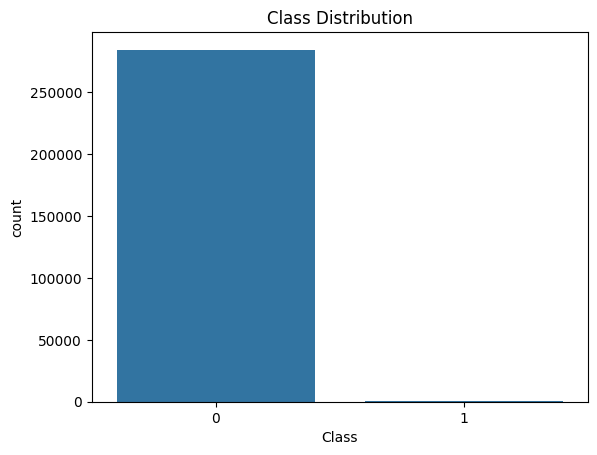

In [ ]:
import numpy as np #Linear Algebra
import pandas as pd #Data processing 
import seaborn as sns # Statistics 
import matplotlib.pyplot as plt #Graphical 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Importing data from kaggle (Download and Importation through Python)
df = pd.read_csv(r'C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\creditcard.csv')

#Plotting class distribution:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

#Feature scalling and train tests...
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, random_state=42)

In [7]:
from sklearn.metrics import precision_score, recall_score, classification_report ,confusion_matrix
import tensorflow as tf

#Build a simple feedforward neural network
#simplest type of artificial neural network 
#where data moves in only one direction—forward—from input nodes, through hidden layers, 
#to output nodes

model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
                       ])

learning_rate = 0.001  # You can adjust this value based on your needs
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Predictions on the test set
y_pred = (model.predict(X_test) > 0.5).astype(int)

def evaluate_model(y_true, y_pred):
    print("Precision Score:", precision_score(y_test, y_pred))
    print("Recall Score:", recall_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
evaluate_model(y_test, y_pred)

Epoch 1/10


c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9989 - loss: 0.0066 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0029
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9993 - val_loss: 0.0030
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9994 - val_loss: 0.0029
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accurac

In [8]:
#Applying isolation forest is unsupervised machine learning algorithm used for anomaly detection 
#that identifies outliers by isolating them, rather than profiling normal data points.

from sklearn.ensemble import IsolationForest
if_model = IsolationForest(contamination=0.02, random_state=42) #contamination = the proportion of outliers in the data set
if_model.fit(X_train)
if_preds = if_model.predict(X_test)
if_preds[if_preds == 1] = 0  # Normal transactions are labeled as 1, so change it to 0
if_preds[if_preds == -1] = 1  # Fraudulent transactions are labeled as -1, so change it to 1
print("Isolation Forest:")
evaluate_model(y_test, if_preds)


Isolation Forest:
Precision Score: 0.06568712186689715
Recall Score: 0.7755102040816326
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.78      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.88      0.56     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:
[[55783  1081]
 [   22    76]]


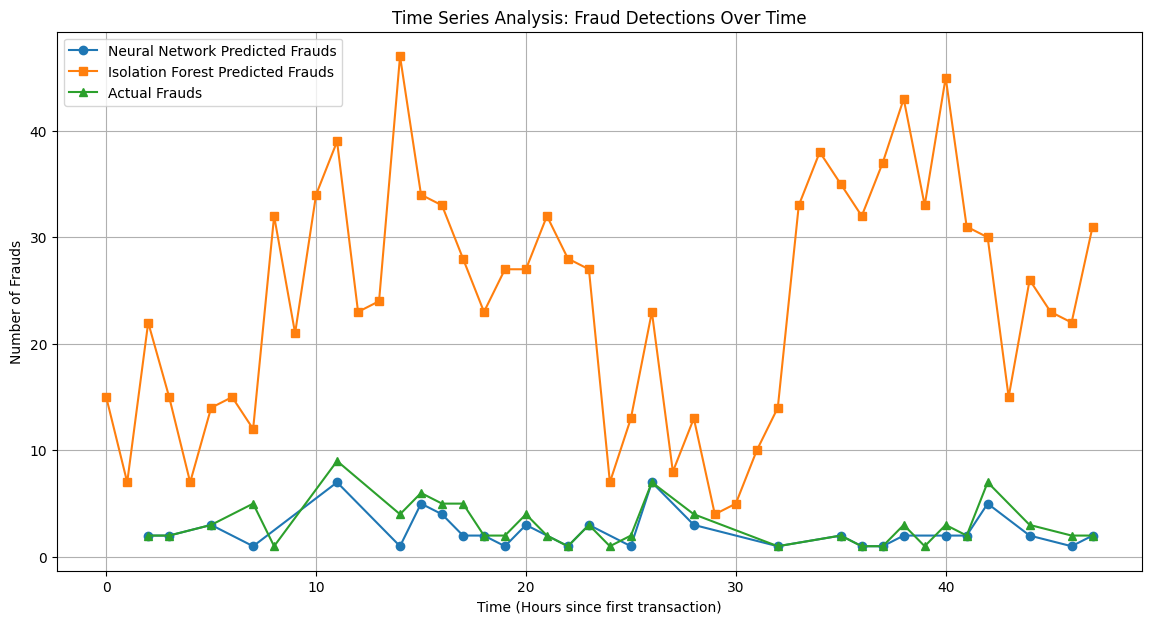

In [10]:
# Time Series Analysis for Fraud Detection
import pandas as pd

# Inverse transform the scaled Time back to original
time_test = scaler.inverse_transform(X_test[['Time']])

# Create a DataFrame with Time, Actual, NN Predictions, IF Predictions
results_df = pd.DataFrame({
    'Time': time_test.flatten(),
    'Actual': y_test.values,
    'NN_Pred': y_pred.flatten(),
    'IF_Pred': if_preds
})

# Sort by Time for time series plotting
results_df = results_df.sort_values('Time')

# Convert Time to hours since the first transaction for better visualization
results_df['Time_Hour'] = (results_df['Time'] // 3600).astype(int)

# Group by hour and count the number of frauds detected/predicted
nn_frauds_per_hour = results_df[results_df['NN_Pred'] == 1].groupby('Time_Hour').size()
if_frauds_per_hour = results_df[results_df['IF_Pred'] == 1].groupby('Time_Hour').size()
actual_frauds_per_hour = results_df[results_df['Actual'] == 1].groupby('Time_Hour').size()

# Plot the time series
plt.figure(figsize=(14, 7))
plt.plot(nn_frauds_per_hour.index, nn_frauds_per_hour.values, label='Neural Network Predicted Frauds', marker='o')
plt.plot(if_frauds_per_hour.index, if_frauds_per_hour.values, label='Isolation Forest Predicted Frauds', marker='s')
plt.plot(actual_frauds_per_hour.index, actual_frauds_per_hour.values, label='Actual Frauds', marker='^')
plt.xlabel('Time (Hours since first transaction)')
plt.ylabel('Number of Frauds')
plt.title('Time Series Analysis: Fraud Detections Over Time')
plt.legend()
plt.grid(True)
plt.show()

Descriptive Statistics for Frauds per Hour:
       Neural Network  Isolation Forest     Actual
count       28.000000         48.000000  32.000000
mean         2.464286         24.104167   3.062500
std          1.710147         11.189356   2.046831
min          1.000000          4.000000   1.000000
25%          1.000000         14.750000   2.000000
50%          2.000000         25.000000   2.000000
75%          3.000000         32.250000   4.000000
max          7.000000         47.000000   9.000000

Correlation between Predicted and Actual Frauds:
Neural Network vs Actual: 0.8514
Isolation Forest vs Actual: 0.1721

Actual Frauds - ADF Test:
ADF Statistic: -5.0717
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.661428725118324), '5%': np.float64(-2.960525341210433), '10%': np.float64(-2.6193188033298647)}
Series is stationary

Neural Network Frauds - ADF Test:
ADF Statistic: -0.8440
p-value: 0.8059
Critical Values: {'1%': np.float64(-3.8326031418574136), '5%': np.float64(-3.0312271

<Figure size 1000x600 with 0 Axes>

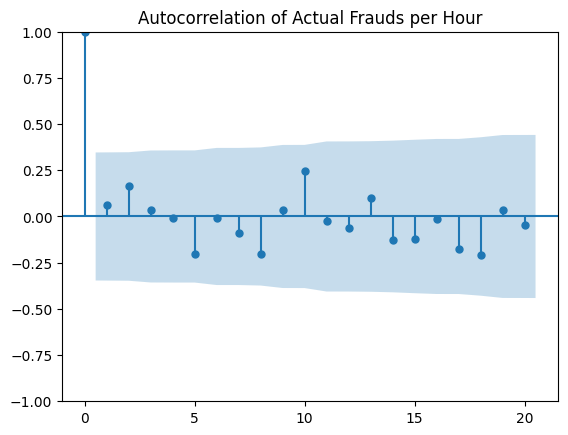


T-test Neural Network vs Actual: t-stat=-1.2183, p-value=0.2281
T-test Isolation Forest vs Actual: t-stat=10.4999, p-value=0.0000


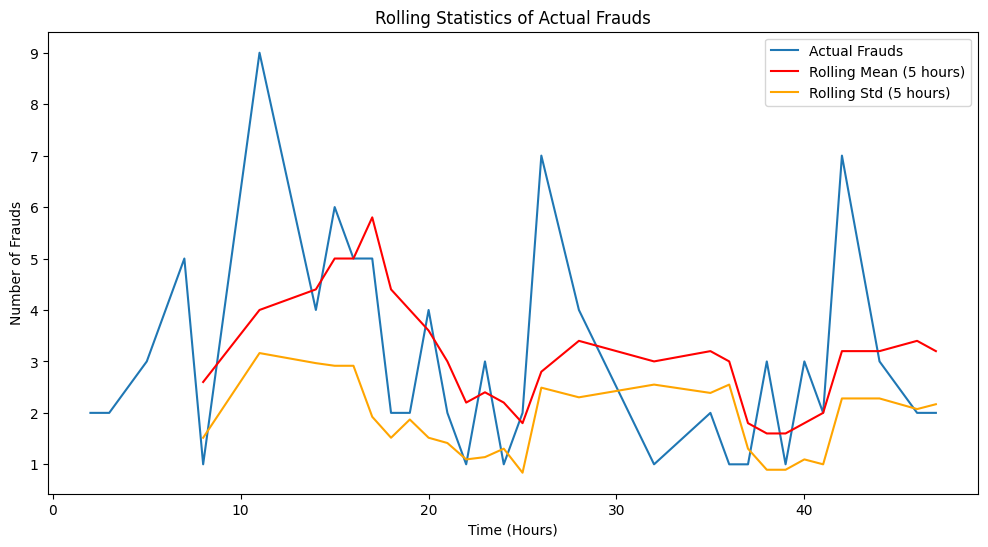

In [11]:
# Statistical Analysis of Fraud Detection Time Series
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# Descriptive Statistics for Frauds per Hour
print("Descriptive Statistics for Frauds per Hour:")
stats_df = pd.DataFrame({
    'Neural Network': nn_frauds_per_hour.describe(),
    'Isolation Forest': if_frauds_per_hour.describe(),
    'Actual': actual_frauds_per_hour.describe()
})
print(stats_df)

# Correlation Analysis
print("\nCorrelation between Predicted and Actual Frauds:")
correlation_nn = nn_frauds_per_hour.corr(actual_frauds_per_hour)
correlation_if = if_frauds_per_hour.corr(actual_frauds_per_hour)
print(f"Neural Network vs Actual: {correlation_nn:.4f}")
print(f"Isolation Forest vs Actual: {correlation_if:.4f}")

# Stationarity Test (Augmented Dickey-Fuller)
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'\n{name} - ADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values: {result[4]}')
    if result[1] < 0.05:
        print("Series is stationary")
    else:
        print("Series is not stationary")

adf_test(actual_frauds_per_hour, 'Actual Frauds')
adf_test(nn_frauds_per_hour, 'Neural Network Frauds')
adf_test(if_frauds_per_hour, 'Isolation Forest Frauds')

# Autocorrelation Plot for Actual Frauds
plt.figure(figsize=(10, 6))
plot_acf(actual_frauds_per_hour.dropna(), lags=20, title='Autocorrelation of Actual Frauds per Hour')
plt.show()

# Hypothesis Testing: Compare mean fraud detections
t_stat_nn, p_val_nn = stats.ttest_ind(nn_frauds_per_hour.dropna(), actual_frauds_per_hour.dropna())
t_stat_if, p_val_if = stats.ttest_ind(if_frauds_per_hour.dropna(), actual_frauds_per_hour.dropna())

print(f"\nT-test Neural Network vs Actual: t-stat={t_stat_nn:.4f}, p-value={p_val_nn:.4f}")
print(f"T-test Isolation Forest vs Actual: t-stat={t_stat_if:.4f}, p-value={p_val_if:.4f}")

# Additional: Rolling mean and std for Actual Frauds
rolling_mean = actual_frauds_per_hour.rolling(window=5).mean()
rolling_std = actual_frauds_per_hour.rolling(window=5).std()

plt.figure(figsize=(12, 6))
plt.plot(actual_frauds_per_hour.index, actual_frauds_per_hour.values, label='Actual Frauds')
plt.plot(rolling_mean.index, rolling_mean.values, label='Rolling Mean (5 hours)', color='red')
plt.plot(rolling_std.index, rolling_std.values, label='Rolling Std (5 hours)', color='orange')
plt.xlabel('Time (Hours)')
plt.ylabel('Number of Frauds')
plt.title('Rolling Statistics of Actual Frauds')
plt.legend()
plt.show()